In [281]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv


In [282]:
train=pd.read_csv('/kaggle/input/titanic/train.csv')

In [283]:
test=pd.read_csv('/kaggle/input/titanic/test.csv')

In [284]:
train.describe(include='all')





,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Nakid, Mr. Sahid",male,NaN,NaN,NaN,1601,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [285]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [286]:
import matplotlib.pyplot as plt
import seaborn as sns

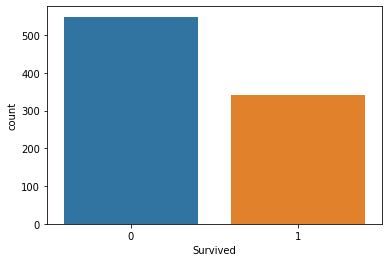

In [287]:
sns.countplot(train['Survived'])

In [288]:
train.isnull().sum().sort_values()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
Age            177
Cabin          687
dtype: int64

In [289]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

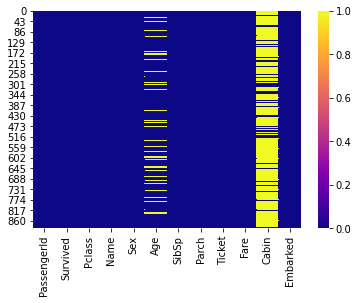

In [290]:
sns.heatmap(train.isnull(), cmap = 'plasma')




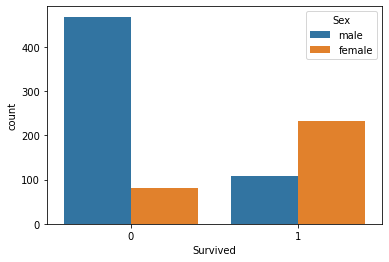

In [291]:


sns.countplot(x = 'Survived', hue = 'Sex', data = train)



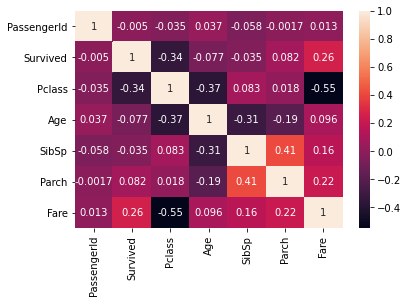

In [292]:
sns.heatmap(train.corr(), annot = True)

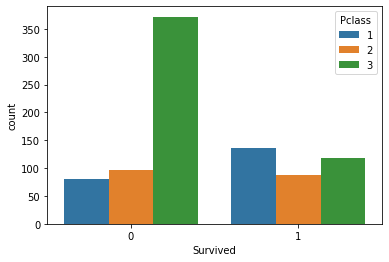

In [293]:

sns.countplot(x = 'Survived', hue = 'Pclass', data = train)

In [294]:
group=train.groupby('Pclass')['Age']
print(group.median())

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64


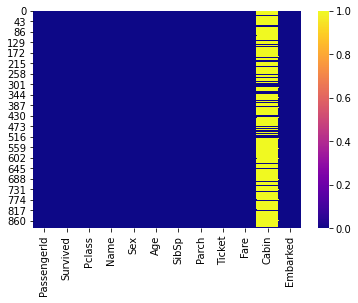

In [295]:
train.loc[train.Age.isnull(), 'Age'] = train.groupby("Pclass").Age.transform('median')

sns.heatmap(train.isnull(), cmap = 'plasma')



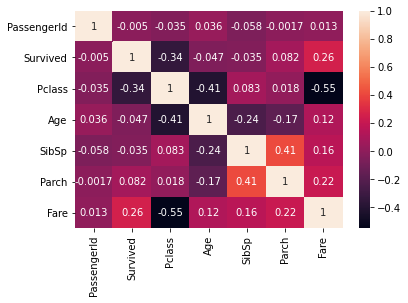

In [296]:
sns.heatmap(train.corr(), annot = True)

In [297]:
# We will get rid of 'Cabin' for now, TOO many missing values!
train.drop('Cabin', axis = 1, inplace = True)

In [298]:
train.isnull().sum().sort_values()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [299]:
from statistics import mode
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
train["Embarked"] = train["Embarked"].fillna(mode(train["Embarked"]))


In [300]:
train.drop(['Name','Ticket'], axis = 1,inplace=True)
labelencoder_X = LabelEncoder()
train['Embarked'] = labelencoder_X.fit_transform(train['Embarked'])
train["Embarked"] = pd.get_dummies(train["Embarked"])
train['Embarked']
train.info()
train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Sex            891 non-null object
Age            891 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Fare           891 non-null float64
Embarked       891 non-null uint8
dtypes: float64(2), int64(5), object(1), uint8(1)
memory usage: 56.7+ KB


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,0
1,2,1,1,female,38.0,1,0,71.2833,1
2,3,1,3,female,26.0,0,0,7.9250,0
3,4,1,1,female,35.0,1,0,53.1000,0
4,5,0,3,male,35.0,0,0,8.0500,0
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,0
887,888,1,1,female,19.0,0,0,30.0000,0
888,889,0,3,female,24.0,1,2,23.4500,0
889,890,1,1,male,26.0,0,0,30.0000,1


In [301]:
train['Sex'] = labelencoder_X.fit_transform(train['Sex'])
train["Sex"] = pd.get_dummies(train["Sex"])
train['Sex']


0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: uint8

In [302]:
X_train, X_test, y_train, y_test = train_test_split(train.drop(['Survived'], axis = 1), 
                                                    train['Survived'], test_size = 0.25, 
                                                    random_state = 0)

In [303]:
from sklearn.linear_model import LogisticRegression
regressor= LogisticRegression()
regressor.fit(X_train,y_train)
y_pred=regressor.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



[[116  23]
 [ 26  58]]
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       139
           1       0.72      0.69      0.70        84

    accuracy                           0.78       223
   macro avg       0.77      0.76      0.76       223
weighted avg       0.78      0.78      0.78       223



In [304]:
train=pd.read_csv('/kaggle/input/titanic/train.csv')
test=pd.read_csv('/kaggle/input/titanic/test.csv')

In [305]:
test['Survived'] = np.nan

full = pd.concat([train, test])

In [306]:
full.isnull().sum().sort_values()

Name              0
Parch             0
PassengerId       0
Pclass            0
Sex               0
SibSp             0
Ticket            0
Fare              1
Embarked          2
Age             263
Survived        418
Cabin          1014
dtype: int64

In [307]:

full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 0 to 417
Data columns (total 12 columns):
Age            1046 non-null float64
Cabin          295 non-null object
Embarked       1307 non-null object
Fare           1308 non-null float64
Name           1309 non-null object
Parch          1309 non-null int64
PassengerId    1309 non-null int64
Pclass         1309 non-null int64
Sex            1309 non-null object
SibSp          1309 non-null int64
Survived       891 non-null float64
Ticket         1309 non-null object
dtypes: float64(3), int64(4), object(5)
memory usage: 132.9+ KB


In [308]:
full["Embarked"] = full["Embarked"].fillna(mode(full["Embarked"]))

In [309]:

full['Embarked'] = labelencoder_X.fit_transform(full['Embarked'])
full["Embarked"] = pd.get_dummies(full["Embarked"])
full['Embarked']
full['Sex'] = labelencoder_X.fit_transform(full['Sex'])
full["Sex"] = pd.get_dummies(full["Sex"])
full['Sex']


0      0
1      1
2      1
3      1
4      0
      ..
413    0
414    1
415    0
416    0
417    0
Name: Sex, Length: 1309, dtype: uint8

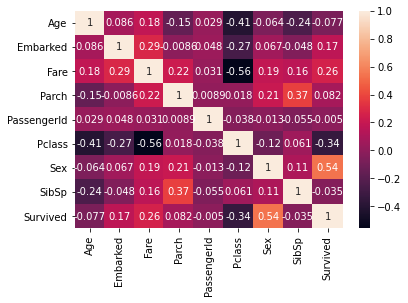

In [310]:
sns.heatmap(full.corr(),annot=True)

In [311]:
full['Age'] = full.groupby("Pclass")['Age'].transform(lambda x: x.fillna(x.median()))

In [312]:
full['Fare']=full.groupby("Pclass")['Fare'].transform(lambda x: x.fillna(x.median()))

In [313]:
full['Cabin'] = full['Cabin'].fillna('U')

In [314]:
full.isnull().sum().sort_values()
# no missing values

Age              0
Cabin            0
Embarked         0
Fare             0
Name             0
Parch            0
PassengerId      0
Pclass           0
Sex              0
SibSp            0
Ticket           0
Survived       418
dtype: int64

In [315]:
full['Cabin'].unique().tolist()

['U',
 'C85',
 'C123',
 'E46',
 'G6',
 'C103',
 'D56',
 'A6',
 'C23 C25 C27',
 'B78',
 'D33',
 'B30',
 'C52',
 'B28',
 'C83',
 'F33',
 'F G73',
 'E31',
 'A5',
 'D10 D12',
 'D26',
 'C110',
 'B58 B60',
 'E101',
 'F E69',
 'D47',
 'B86',
 'F2',
 'C2',
 'E33',
 'B19',
 'A7',
 'C49',
 'F4',
 'A32',
 'B4',
 'B80',
 'A31',
 'D36',
 'D15',
 'C93',
 'C78',
 'D35',
 'C87',
 'B77',
 'E67',
 'B94',
 'C125',
 'C99',
 'C118',
 'D7',
 'A19',
 'B49',
 'D',
 'C22 C26',
 'C106',
 'C65',
 'E36',
 'C54',
 'B57 B59 B63 B66',
 'C7',
 'E34',
 'C32',
 'B18',
 'C124',
 'C91',
 'E40',
 'T',
 'C128',
 'D37',
 'B35',
 'E50',
 'C82',
 'B96 B98',
 'E10',
 'E44',
 'A34',
 'C104',
 'C111',
 'C92',
 'E38',
 'D21',
 'E12',
 'E63',
 'A14',
 'B37',
 'C30',
 'D20',
 'B79',
 'E25',
 'D46',
 'B73',
 'C95',
 'B38',
 'B39',
 'B22',
 'C86',
 'C70',
 'A16',
 'C101',
 'C68',
 'A10',
 'E68',
 'B41',
 'A20',
 'D19',
 'D50',
 'D9',
 'A23',
 'B50',
 'A26',
 'D48',
 'E58',
 'C126',
 'B71',
 'B51 B53 B55',
 'D49',
 'B5',
 'B20',
 'F G

In [316]:
# Let's import our regular expression matching operations module!
import re

# Extract (first) letter!
full['Cabin'] = full['Cabin'].map(lambda x: re.compile("([a-zA-Z]+)").search(x).group())
full['Cabin'].unique().tolist()

['U', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']

In [317]:
cabin_category = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7, 'T':8, 'U':9}
full['Cabin'] = full['Cabin'].map(cabin_category)
full['Cabin'].unique().tolist()

[9, 3, 5, 7, 4, 1, 2, 6, 8]

In [318]:
# Extract the salutation!
full['Title'] = full.Name.str.extract(' ([A-Za-z]+)\.', expand = False)
full['Title'].unique().tolist()

['Mr',
 'Mrs',
 'Miss',
 'Master',
 'Don',
 'Rev',
 'Dr',
 'Mme',
 'Ms',
 'Major',
 'Lady',
 'Sir',
 'Mlle',
 'Col',
 'Capt',
 'Countess',
 'Jonkheer',
 'Dona']

In [319]:
# Look at salutations percentages
full['Title'].value_counts(normalize = True) * 100

Mr          57.830405
Miss        19.862490
Mrs         15.049656
Master       4.660046
Dr           0.611154
Rev          0.611154
Col          0.305577
Major        0.152788
Ms           0.152788
Mlle         0.152788
Don          0.076394
Dona         0.076394
Lady         0.076394
Mme          0.076394
Sir          0.076394
Countess     0.076394
Jonkheer     0.076394
Capt         0.076394
Name: Title, dtype: float64

In [320]:
#  Bundle rare salutations: 'Other' category
full['Title'] = full['Title'].replace(['Rev', 'Dr', 'Col', 'Ms', 'Mlle', 'Major', 'Countess', 
                                       'Capt', 'Dona', 'Jonkheer', 'Lady', 'Sir', 'Mme', 'Don'], 'Other')

In [321]:
title_category = {'Mr':1, 'Miss':2, 'Mrs':3, 'Master':4, 'Other':5}
full['Title'] = full['Title'].map(title_category)
full['Title'].unique().tolist()

[1, 3, 2, 4, 5]

In [322]:
print(full.columns.tolist())

['Age', 'Cabin', 'Embarked', 'Fare', 'Name', 'Parch', 'PassengerId', 'Pclass', 'Sex', 'SibSp', 'Survived', 'Ticket', 'Title']


In [323]:
full['familySize'] = full['SibSp'] + full['Parch'] + 1

In [324]:
print(full.head())


    Age  Cabin  Embarked     Fare  \
0  22.0      9         0   7.2500   
1  38.0      3         1  71.2833   
2  26.0      9         0   7.9250   
3  35.0      3         0  53.1000   
4  35.0      9         0   8.0500   

                                                Name  Parch  PassengerId  \
0                            Braund, Mr. Owen Harris      0            1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...      0            2   
2                             Heikkinen, Miss. Laina      0            3   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)      0            4   
4                           Allen, Mr. William Henry      0            5   

   Pclass  Sex  SibSp  Survived            Ticket  Title  familySize  
0       3    0      1       0.0         A/5 21171      1           2  
1       1    1      1       1.0          PC 17599      3           2  
2       3    1      0       1.0  STON/O2. 3101282      2           1  
3       1    1      1       1.0     

In [325]:
# Drop redundant features
full = full.drop(['Name', 'SibSp', 'Parch', 'Ticket'], axis = 1)

In [326]:
full.head()

,Age,Cabin,Embarked,Fare,PassengerId,Pclass,Sex,Survived,Title,familySize
0,22.0,9,0,7.2500,1,3,0,0.0,1,2
1,38.0,3,1,71.2833,2,1,1,1.0,3,2
2,26.0,9,0,7.9250,3,3,1,1.0,2,1
3,35.0,3,0,53.1000,4,1,1,1.0,3,2
4,35.0,9,0,8.0500,5,3,0,0.0,1,1


In [327]:
# Recover test dataset
test = full[full['Survived'].isna()].drop(['Survived'], axis = 1)
test

,Age,Cabin,Embarked,Fare,PassengerId,Pclass,Sex,Title,familySize
0,34.5,9,0,7.8292,892,3,0,1,1
1,47.0,9,0,7.0000,893,3,1,3,2
2,62.0,9,0,9.6875,894,2,0,1,1
3,27.0,9,0,8.6625,895,3,0,1,1
4,22.0,9,0,12.2875,896,3,1,3,3
...,...,...,...,...,...,...,...,...,...
413,24.0,9,0,8.0500,1305,3,0,1,1
414,39.0,3,1,108.9000,1306,1,1,5,1
415,38.5,9,0,7.2500,1307,3,0,1,1
416,24.0,9,0,8.0500,1308,3,0,1,1


In [328]:
full


,Age,Cabin,Embarked,Fare,PassengerId,Pclass,Sex,Survived,Title,familySize
0,22.0,9,0,7.2500,1,3,0,0.0,1,2
1,38.0,3,1,71.2833,2,1,1,1.0,3,2
2,26.0,9,0,7.9250,3,3,1,1.0,2,1
3,35.0,3,0,53.1000,4,1,1,1.0,3,2
4,35.0,9,0,8.0500,5,3,0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...
413,24.0,9,0,8.0500,1305,3,0,NaN,1,1
414,39.0,3,1,108.9000,1306,1,1,NaN,5,1
415,38.5,9,0,7.2500,1307,3,0,NaN,1,1
416,24.0,9,0,8.0500,1308,3,0,NaN,1,1


In [329]:
# Recover train dataset
train = full[full['Survived'].notna()]

In [330]:
train

,Age,Cabin,Embarked,Fare,PassengerId,Pclass,Sex,Survived,Title,familySize
0,22.0,9,0,7.2500,1,3,0,0.0,1,2
1,38.0,3,1,71.2833,2,1,1,1.0,3,2
2,26.0,9,0,7.9250,3,3,1,1.0,2,1
3,35.0,3,0,53.1000,4,1,1,1.0,3,2
4,35.0,9,0,8.0500,5,3,0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...
886,27.0,9,0,13.0000,887,2,0,0.0,5,1
887,19.0,2,0,30.0000,888,1,1,1.0,2,1
888,24.0,9,0,23.4500,889,3,1,0.0,2,4
889,26.0,3,1,30.0000,890,1,0,1.0,1,1


In [331]:
# Cast 'Survived' back to integer
train['Survived'] = train['Survived'].astype(np.int8)

In [332]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(train.drop(['Survived', 'PassengerId'], axis = 1), 
                                                    train['Survived'], test_size = 0.25, 
                                                    random_state = 0)

In [333]:
# We'll use a logistic regression model again, but we'll go to something more fancy soon! 
from sklearn.linear_model import LogisticRegression
logisticRegression = LogisticRegression()
logisticRegression.fit(X_train, y_train)
predictions = logisticRegression.predict(X_test)

In [334]:
from sklearn.metrics import classification_report, confusion_matrix

# Print the resulting confusion matrix
print(confusion_matrix(y_test, predictions))
classification_report(y_test,predictions)

[[113  26]
 [ 20  64]]


'              precision    recall  f1-score   support\n\n           0       0.85      0.81      0.83       139\n           1       0.71      0.76      0.74        84\n\n    accuracy                           0.79       223\n   macro avg       0.78      0.79      0.78       223\nweighted avg       0.80      0.79      0.80       223\n'

In [335]:
from sklearn.model_selection import KFold

# Set our robust cross-validation scheme!
kf = KFold(n_splits = 10, random_state = 0)

In [336]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
logisticRegression=LogisticRegression()
# Print our CV accuracy estimate:
cross_val_score(logisticRegression, X_test, y_test, cv = kf).mean()

0.7660079051383399

In [337]:
from sklearn.ensemble import RandomForestClassifier

#Initialize randomForest
randomForest = RandomForestClassifier(random_state = 0)

In [338]:
# Set our parameter grid
param_grid = { 
    'criterion' : ['gini', 'entropy'],
    'n_estimators': [100, 300, 500],
    'max_features': ['auto', 'log2'],
    'max_depth' : [3, 5, 7]    
}

In [339]:
# Grid search for best grid
from sklearn.model_selection import GridSearchCV


randomForest_CV = GridSearchCV(estimator = randomForest, param_grid = param_grid, cv = 5)
randomForest_CV.fit(X_train, y_train)

GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False, random_state=0,
                                   

In [340]:
# Print best hyperparameters
randomForest_CV.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'auto',
 'n_estimators': 100}

In [341]:
# Define our optimal randomForest algo
randomForestFinalModel = RandomForestClassifier(random_state = 0, 
criterion = 'gini', max_depth = 5, max_features = 'auto', n_estimators = 100)

In [342]:
# Fit the model to the training set
randomForestFinalModel.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=5, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0,
                       warm_start=False)

In [343]:
pred = randomForestFinalModel.predict(X_test)

In [344]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy for our powerful random forest!
print("accuracy is: ", round(accuracy_score(y_test, pred), 2))

accuracy is:  0.82


In [345]:
# Predict!
test['Survived'] = randomForestFinalModel.predict(test)

ValueError: Number of features of the model must match the input. Model n_features is 8 and input n_features is 9 

In [ ]:
# Write test predictions for final submission
test[['PassengerId', 'Survived']].to_csv('rf_submission.csv', index = False)